# Responsible AI in Bank Marketing.


## Main Research Question

**Can a machine learning model predict bank term deposit subscriptions accurately while maintaining fair and explainable outcomes across customer groups?**

## Responsible AI Concepts Used

- **Bias and fairness:** Evaluate whether model outcomes differ across age groups.
- **Bias mitigation:** SMOTE to address class imbalance.
- **Explainability:** SHAP to understand which features drive predictions.
- **Governance:** Safeguard recommendations for a real-life application.

##**Notebook Setup**

1. Install Fairlearn Library


In [2]:
!pip -q install fairlearn imbalanced-learn shap ucimlrepo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.6 MB/s eta 0:00:00


2. Import Libraries

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fairlearn.datasets import fetch_bank_marketing
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

RANDOM_STATE = 42

## Load Dataset

The Bank Marketing dataset comes from the "UC Irvine Machine Learning Repository" and it's based on direct marketing campaigns (phone calls) from a Portuguese banking institution.The classification goal is to predict if the client will subscribe a term deposit

This project will access the dataset through Fairlearn.

In [4]:
data = fetch_bank_marketing(as_frame=True)

#Ensure Fairlearn fetches the complete data frame and
#not the target variable as a separate
if hasattr(data, "frame") and data.frame is not None:
    df = data.frame.copy()
else:
    df = pd.concat([data.data.copy(), data.target.rename("y")], axis=1)

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (45211, 17)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1



Columns:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'Class']


We have a dataset that contains 45,211 observations with 16 features (not including our target).

Target column is "class" and it is binary (0 =no ,1=yes).

In [5]:
df.columns = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "day",
    "month",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "poutcome",
    "Class"
]

display(df.head())
print(df.columns.tolist())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'Class']


## Data Exploration

In [6]:
#double check for missing values -
#UCI says there is none, except for contact,pdays and poutcome
print("Missing values by column:")
display(df.isna().sum())

#look at our target's distribution
print("\nTarget distribution:")
display(df["Class"].value_counts())

print("\nTarget distribution as percentages:")
display(df["Class"].value_counts(normalize=True).round(4) * 100)

Missing values by column:


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0



Target distribution:


,count
Class,
1,39922
2,5289



Target distribution as percentages:


,proportion
Class,
1,88.3
2,11.7


Visualizing Target Distribution

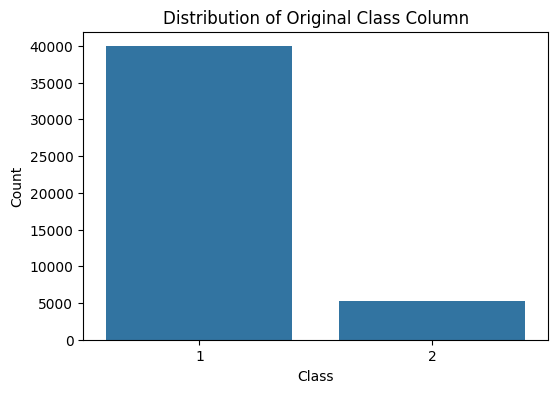

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df) # Use original df and 'Class' column
plt.title('Distribution of Original Class Column')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Class has been coded as 2 and 1. To make it clearer this will be adjusted to 0 and 1. Given the distribution I can assume 1= No and 2 = Yes

There is also a significant class imbalance.With most people in the dataset having not subscribed to the financial test. This class imbalance will be handled later, as this can significantly impact how the model performs for one class vs the other.

##Handling Missing Values

At a first glance it looks like there is no missing values. However, in the dataset information we find that they didn't code them as n/a but rather were coded as their own categorical "unkown" value.

In [7]:
unknown_counts = {}
for column in df.columns:
    # Handle categorical columns explicitly if they might contain 'unknown'
    if pd.api.types.is_categorical_dtype(df[column]):
        if 'unknown' in df[column].cat.categories:
           count = (df[column] == 'unknown').sum()
           if count > 0:
                unknown_counts[column] = count

if unknown_counts:
    print("Counts of 'unknown' values by column:")
    for col, count in unknown_counts.items():
        print(f"{col}: {count}")
else:
    print("No 'unknown' values found in object or categorical columns.")

Counts of 'unknown' values by column:
job: 288
education: 1857
contact: 13020
poutcome: 36959


We have "unkown" values in 4 categories. Given the number of rows that have "missing" values (especially looking at "poutcome" and "contact") and the responsible AI context of the project, my first instict is keep the rows as their own category. This allows us to study/audit whether missingness itself influences predections. For example, an assumption I can make before auditing could be that "unkown" job and education are used as important features.

However, I will explore further to see if these values are missing at random (MAR), completely at random (MCAR), or not at random (MNAR). I will compare unkown rates across target variable and age groups and use chi-square test. This will not prove 100% explain the reason for missingness but it will allow to see in more details if missing values follow a systematic order.


In [10]:
#To assess missigness againts age, I will group ages as each individual value
#is too granular. This is also helpful to later audit the broader fairness across ages.

# Create age groups from the numeric age variable
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["under_30", "30_45", "46_60", "over_60"],
    include_lowest=True
)

# Check the new age_group variable
display(df[["age", "age_group"]].head())

# Check how many clients are in each age group
display(df["age_group"].value_counts().sort_index())

,age,age_group
0,58,46_60
1,44,30_45
2,33,30_45
3,47,46_60
4,33,30_45


,count
age_group,
under_30,7030
30_45,23733
46_60,13260
over_60,1188


In [11]:
unknown_cols = ["job", "education", "contact", "poutcome"]

for col in unknown_cols:
    df[f"{col}_is_unknown"] = (df[col] == "unknown").astype(int)

# Unknown rates by target
for col in unknown_cols:
    indicator = f"{col}_is_unknown"
    print(f"\nUnknown rate for {col} by target:")
    display(df.groupby("Class")[indicator].mean().reset_index(name="unknown_rate"))

# Unknown rates by age group
for col in unknown_cols:
    indicator = f"{col}_is_unknown"
    print(f"\nUnknown rate for {col} by age group:")
    display(df.groupby("age_group")[indicator].mean().reset_index(name="unknown_rate"))


Unknown rate for job by target:


,Class,unknown_rate
0,1,0.006362
1,2,0.006428



Unknown rate for education by target:


,Class,unknown_rate
0,1,0.040203
1,2,0.047646



Unknown rate for contact by target:


...

,age_group,unknown_rate
0,under_30,0.033713
1,30_45,0.031770
2,46_60,0.057164
3,over_60,0.090909



Unknown rate for contact by age group:


,age_group,unknown_rate
0,under_30,0.274680
1,30_45,0.298951
2,46_60,0.299925
3,over_60,0.014310



Unknown rate for poutcome by age group:


,age_group,unknown_rate
0,under_30,0.817070
1,30_45,0.811275
2,46_60,0.845249
3,over_60,0.633838


In [13]:
from scipy.stats import chi2_contingency

test_vars = ["Class", "age_group", "housing", "loan", "marital"]
chi_square_results = []

for unknown_col in unknown_cols:
    indicator = f"{unknown_col}_is_unknown"

    for var in test_vars:
        contingency_table = pd.crosstab(df[indicator], df[var])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        chi_square_results.append({
            "unknown_column": unknown_col,
            "tested_against": var,
            "p_value": p_value
        })

chi_square_results_df = pd.DataFrame(chi_square_results)
display(chi_square_results_df.sort_values("p_value"))

,unknown_column,tested_against,p_value
12,contact,housing,0.000000e+00
15,poutcome,Class,4.770624e-276
10,contact,Class,9.240410e-226
11,contact,age_group,4.621433e-100
16,poutcome,age_group,4.484895e-74
2,job,housing,7.140491e-57
6,education,age_group,2.879456e-48
17,poutcome,housing,8.603544e-42
8,education,loan,3.059573e-26
1,job,age_group,2.087373e-24


The missing/unknown values do not appear to be completely random. Several unknown indicators differ across target outcomes and age groups, and chi-square tests show significant associations between unknownness and observed variables. **Therefore, I kept "unknown" as an explicit category rather than deleting or imputing it.**

Job:
With target var:
For "job" the class distribution with target seems to be almost the same, suggesting that the unkown values are not meaningfully different by target.

Age group: Unkown is highest for clients over 60 and lowest for clients under 30, suggesting a relation.

Education:
With target var:
In "Education", subscribers seems to have a higher number of "unkown" rows and the p-value suggests a slight but practical difference.
Age group: Unkown education is highest for older clients as well. If missigness is used as a predidction, these could affect how certain age groups are treated.

Contact:
With target var:
Customers who didn't subscribe seem to have unkown contact methods about 30% of the time while those who did subscribe only about 10%. The p-value is also high, suggesting that this is not just missigness noise. This is likely a recording and campaign process issue.
Age group: Contact method is unkown for about 27-30% for customers under 60, but only 1.4% for over 60.

Pouctome:
With target var:
Unknown previous campaign outcome is very common overall, but it is especially common among non-subscribers, which suggest this is informative.
Age: Unknown previous campaign outcome is common in all groups, but much lower for the over-60 group.

The chi-square tests shows multiple values < 0.05 therefore as statistically significant. (Given the size of the datasets, these are taken with caution)

###Checking numeric values for impossible values

In [15]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_summary = df[numeric_cols].describe().T

numeric_summary["num_negative"] = (df[numeric_cols] < 0).sum()
numeric_summary["num_zero"] = (df[numeric_cols] == 0).sum()

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,num_negative,num_zero
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0,0,0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0,3766,3514
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0,0,0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0,0,3
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0,0,0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0,36954,0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0,0,36954
job_is_unknown,45211.0,0.006370,0.079559,0.0,0.0,0.0,0.0,1.0,0,44923
education_is_unknown,45211.0,0.041074,0.198464,0.0,0.0,0.0,0.0,1.0,0,43354
contact_is_unknown,45211.0,0.287983,0.452828,0.0,0.0,0.0,1.0,1.0,0,32191


From this summary, multiple things stand out:


*   P days has negative values -1 which is "impossibly". Based on the dataset information, this is a special code for "never contacted".
*   Balance has negative values, but these are valid. However, the very high max might indicate outliers.
*   Previous, which is the number of contacts previosuly performed with this client (different campaign) seems to have a very extreme value as well.





In [17]:
"""
Previous days will be handled by creating a different binary column to check whether the client
was previously contacted or not. This will the model treating as -1 as a real world value.
However, I acknowledge that this results in missing the information of how many days ago the client
was last contacted.
"""
df["was_previously_contacted"] = (df["pdays"] != -1).astype(int)

# Drop original pdays to avoid treating -1 as a true numeric day value
df = df.drop(columns=["pdays"])


###Checking & Handling Outliers

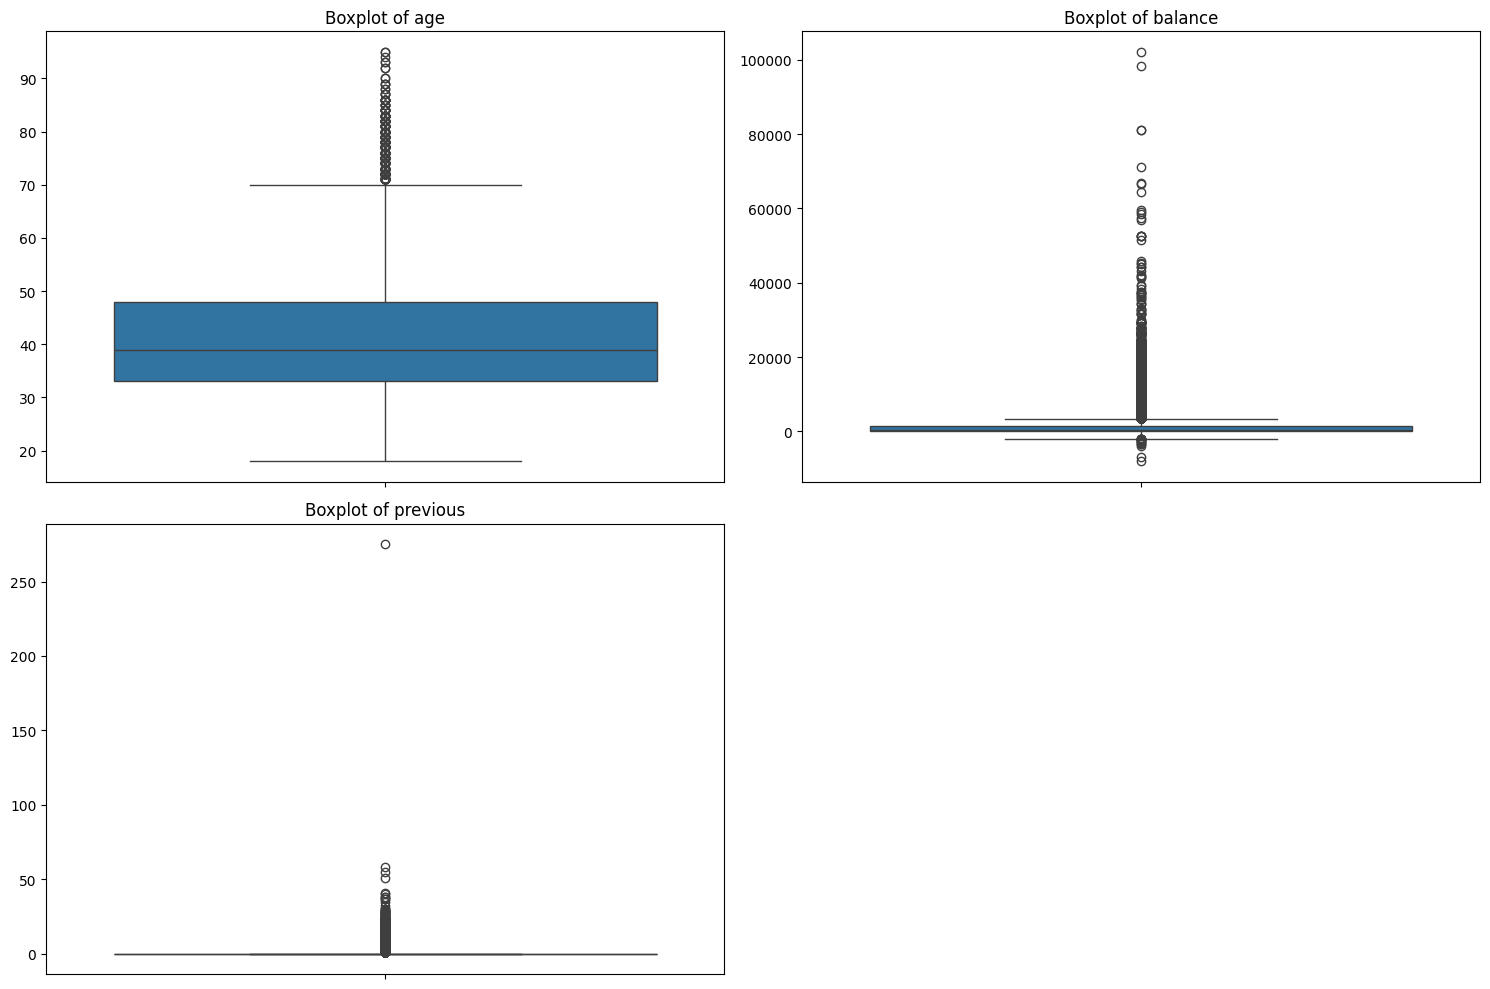

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude binary indicator columns
numeric_cols_for_outliers = ["age", "balance", "previous"]
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols_for_outliers, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

Age: Older ages appear as statistical outliers in the boxplot, but these are real plausible values therefore these will be retained.

Balance: Appears to be heavily skewed. Most customers clustered near lower balances, but some very high balances above 100,000. These values can be real, but extreme values can heavily influence models.

Previous seems highly unusual. Most clients at 0 and lower values, but there is a extreme of 275.

In [22]:
outlier_cols = ["age", "balance", "previous"]

outlier_summary = df[outlier_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995]
).T

display(outlier_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,99.5%,max
age,45211.0,40.936210,10.618762,18.0,23.0,27.0,33.0,39.0,48.0,59.0,71.0,77.00,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,-627.0,-172.0,72.0,448.0,1428.0,5768.0,13164.9,18014.35,102127.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,0.0,0.0,3.0,8.9,12.00,275.0


In [24]:
# Highest balance clients
display(
    df[["age", "job", "education", "balance", "housing", "loan", "Class"]]
    .sort_values("balance", ascending=False)
    .head(10)
)

# Lowest balance clients
display(
    df[["age", "job", "education", "balance", "housing", "loan", "Class"]]
    .sort_values("balance", ascending=True)
    .head(10)
)

# Highest previous contact counts
display(
    df[["age", "job", "education", "previous", "poutcome", "Class"]]
    .sort_values("previous", ascending=False)
    .head(10)
)

,age,job,education,balance,housing,loan,Class
39989,51,management,tertiary,102127,no,no,1
26227,59,management,tertiary,98417,no,no,1
43393,84,retired,secondary,81204,no,no,2
42558,84,retired,secondary,81204,no,no,2
41693,60,retired,primary,71188,no,no,1
19785,56,management,tertiary,66721,no,no,1
21192,52,blue-collar,primary,66653,no,no,1
19420,59,admin.,unknown,64343,no,no,1
41374,32,entrepreneur,tertiary,59649,no,no,1
12926,56,blue-collar,secondary,58932,no,no,1


,age,job,education,balance,housing,loan,Class
12909,26,blue-collar,secondary,-8019,no,yes,1
15682,49,management,tertiary,-6847,no,yes,1
38736,60,management,tertiary,-4057,yes,no,1
7413,43,management,tertiary,-3372,yes,no,1
1896,57,self-employed,tertiary,-3313,yes,yes,1
32713,39,self-employed,tertiary,-3058,yes,yes,2
18573,40,technician,tertiary,-2827,yes,yes,1
31509,52,management,tertiary,-2712,yes,yes,1
25119,49,blue-collar,primary,-2604,yes,no,1
14434,51,management,tertiary,-2282,yes,yes,1


,age,job,education,previous,poutcome,Class
29182,40,management,tertiary,275,other,1
38326,46,blue-collar,primary,58,other,2
44089,37,technician,secondary,55,failure,2
28886,31,management,tertiary,51,failure,1
44822,27,blue-collar,secondary,41,other,1
42611,35,technician,secondary,40,other,1
37567,39,management,tertiary,38,failure,1
28498,49,management,tertiary,38,failure,1
42422,27,student,secondary,37,other,1
26668,51,entrepreneur,secondary,37,other,1


I will cap "balance" at the 1st and 99th percentiles because negative and high values are possible but the distribution is highly skewed. Caping reduces the influence of these extreme values without deleting valid records.

In previous, most clients had zero previous campaign contacts, with one extreme value of 275. Because this value may reflect a real historical record but could disproportionately influence the model, I capped previous at the 99th percentile rather than deleting the record.



In [25]:
# Cap balance at 1st and 99th percentiles
balance_lower = df["balance"].quantile(0.01)
balance_upper = df["balance"].quantile(0.99)

df["balance_capped"] = df["balance"].clip(
    lower=balance_lower,
    upper=balance_upper
)

# Cap previous at 99th percentile
previous_upper = int(np.ceil(df["previous"].quantile(0.99)))

df["previous_capped"] = df["previous"].clip(
    upper=previous_upper
)

print(f"Balance capped between {balance_lower:.2f} and {balance_upper:.2f}")
print(f"Previous capped at {previous_upper}")

Balance capped between -627.00 and 13164.90
Previous capped at 9


### Excluding "duration" and "campaign" feature

The variable "duration" represents the length of the last contact with a customer.  According to UCI dataset info: "Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model."  

Campaign includes the number of outreach efforts that were made during this campaign, including last time, which would not be available at the time the model is intented to be used.

Therefore, duration and campaign are excluded in this project. This is a responsible AI decision because it avoids using a feature that would not be available at decision time and ensures we don't have data leakage from it.

In [30]:
#Standarize Target Variable
df["target"] = df["Class"].map({"1": 0, "2": 1}).astype(int)

#Drop original target column, duration,original balance, and features created to count for unkown values.

df_model = df.drop(
    columns=[
        "Class",
        "duration",
        "campaign",
        "balance",
        "previous",
        "job_is_unknown",
        "education_is_unknown",
        "contact_is_unknown",
        "poutcome_is_unknown"
    ],
    errors="ignore"
)
print("Prepared dataset shape:", df_model.shape)

Prepared dataset shape: (45211, 16)


In [32]:
df_model.head()

,age,job,marital,education,default,housing,loan,contact,day,month,poutcome,age_group,was_previously_contacted,balance_capped,previous_capped,target
0,58,management,married,tertiary,no,yes,no,unknown,5,may,unknown,46_60,0,2143.0,0,0
1,44,technician,single,secondary,no,yes,no,unknown,5,may,unknown,30_45,0,29.0,0,0
2,33,entrepreneur,married,secondary,no,yes,yes,unknown,5,may,unknown,30_45,0,2.0,0,0
3,47,blue-collar,married,unknown,no,yes,no,unknown,5,may,unknown,46_60,0,1506.0,0,0
4,33,unknown,single,unknown,no,no,no,unknown,5,may,unknown,30_45,0,1.0,0,0


## Sensitive features specific exploratory analysis

Examine the overall subscription rate and compare it across age groups and education.

Overall subscription rate: 0.117


,age_group,count,mean,subscription_rate_percent
0,under_30,7030,0.162873,16.287340
1,30_45,23733,0.098808,9.880757
2,46_60,13260,0.097813,9.781297
3,over_60,1188,0.422559,42.255892


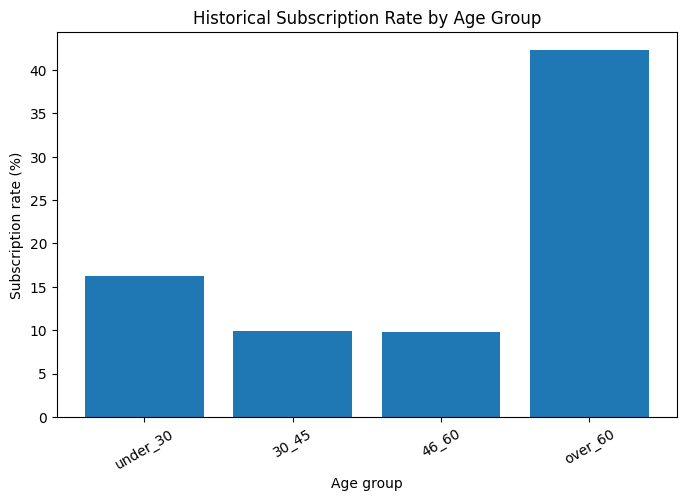

In [33]:
overall_rate = df_model["target"].mean()
print(f"Overall subscription rate: {overall_rate:.3f}")

age_rates = df_model.groupby("age_group")["target"].agg(["count", "mean"]).reset_index()
age_rates["subscription_rate_percent"] = age_rates["mean"] * 100
display(age_rates)

plt.figure(figsize=(8, 5))
plt.bar(age_rates["age_group"].astype(str), age_rates["subscription_rate_percent"])
plt.xlabel("Age group")
plt.ylabel("Subscription rate (%)")
plt.title("Historical Subscription Rate by Age Group")
plt.xticks(rotation=30)
plt.show()

We can see that the over 60 group has a higher subscription rate than other groups about 42.3% ( but this group is also the smallest). This suggests that age is associated with the target outcome in the historical data. This is important because a model trained on this data may learn to prioritize age groups with historically higher subscription rates. This does not automatically mean the model is unfair, but it does mean age-group should be a point of consideration in auditing.

,education,count,mean,subscription_rate_percent
0,tertiary,13301,0.150064,15.006390
1,unknown,1857,0.135703,13.570275
2,secondary,23202,0.105594,10.559435
3,primary,6851,0.086265,8.626478


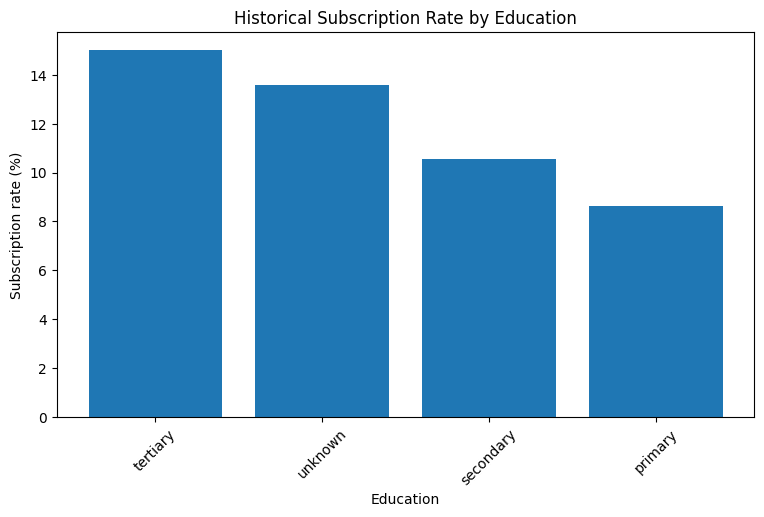

In [34]:
#Subscription rate by education
education_rates = (
    df_model.groupby("education")["target"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
    .reset_index()
)
education_rates["subscription_rate_percent"] = education_rates["mean"] * 100
display(education_rates)

plt.figure(figsize=(9, 5))
plt.bar(education_rates["education"].astype(str), education_rates["subscription_rate_percent"])
plt.xlabel("Education")
plt.ylabel("Subscription rate (%)")
plt.title("Historical Subscription Rate by Education")
plt.xticks(rotation=45)
plt.show()

The subscription rate also varied by education level. Clients with tertiary education had the highest subscription rate at approximately 15.1%, while clients with primary education had the lowest rate at approximately 8.6%. Since education may reflect socioeconomic differences, this feature should be reviewed carefully.

## Prepare Features and Train/Test Split

The model predicts whether a client subscribed to a term deposit.

In [37]:
X = df_model.drop(columns=["target", "age_group"])
y = df_model["target"]
sensitive_age_group = df_model["age_group"]

X_train, X_test, y_train, y_test, age_train, age_test = train_test_split(
    X,
    y,
    sensitive_age_group,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).round(4))
print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).round(4))

Train shape: (33908, 14)
Test shape: (11303, 14)

Training target distribution:


,proportion
target,
0,0.883
1,0.117



Testing target distribution:


,proportion
target,
0,0.883
1,0.117


## Build Preprocessing Pipeline

The dataset contains both numeric and categorical features. Numeric features are scaled for logistic regression, and categorical features are one-hot encoded.

The same preprocessing object will be reused across models so comparisons are fair.

In [38]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Binary numeric features that should be passed through without scaling
binary_features = ["was_previously_contacted"]

# Continuous numeric features that should be scaled
continuous_numeric_features = [
    col for col in numeric_features
    if col not in binary_features
]

print("Continuous numeric features:", continuous_numeric_features)
print("Binary features:", binary_features)
print("Categorical features:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_numeric_features),
        ("binary", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Continuous numeric features: ['age', 'day', 'balance_capped', 'previous_capped']
Binary features: ['was_previously_contacted']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Helper Function for Model Evaluation

In [39]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc = np.nan

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": auc
    }

    print(f"\n{model_name} Classification Report")
    print(classification_report(y_test, y_pred, target_names=["No Subscription", "Subscription"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"])
    disp.plot()
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

    return metrics, y_pred, y_proba

## Train Baseline Models

This project uses two models:

1. **Logistic Regression** as an interpretable baseline.
2. **Random Forest** as a more flexible model that can capture nonlinear relationships.

The Random Forest model will later be explained using SHAP.


Logistic Regression Classification Report
                 precision    recall  f1-score   support

No Subscription       0.94      0.77      0.85      9981
   Subscription       0.27      0.63      0.37      1322

       accuracy                           0.75     11303
      macro avg       0.60      0.70      0.61     11303
   weighted avg       0.86      0.75      0.79     11303



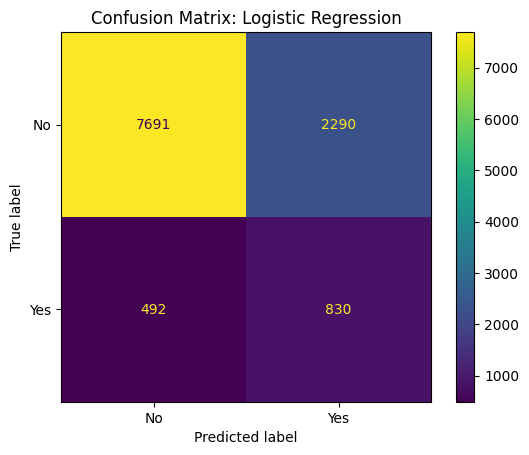


Random Forest Classification Report
                 precision    recall  f1-score   support

No Subscription       0.94      0.85      0.89      9981
   Subscription       0.35      0.60      0.44      1322

       accuracy                           0.82     11303
      macro avg       0.64      0.73      0.67     11303
   weighted avg       0.87      0.82      0.84     11303



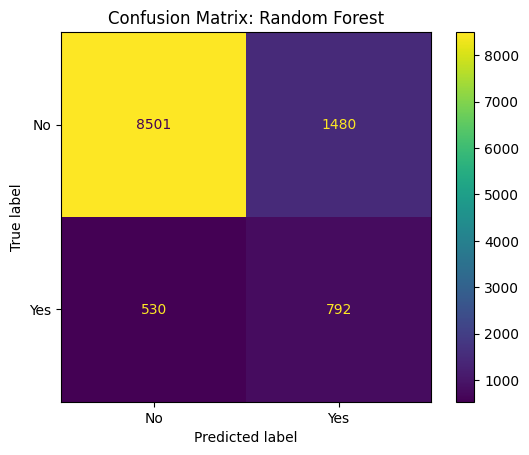

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.7539,0.2660,0.6278,0.3737,0.7695
1,Random Forest,0.8222,0.3486,0.5991,0.4407,0.7939


In [40]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)

log_metrics, log_pred, log_proba = evaluate_model(log_reg, X_test, y_test, "Logistic Regression")
rf_metrics, rf_pred, rf_proba = evaluate_model(rf, X_test, y_test, "Random Forest")

baseline_results = pd.DataFrame([log_metrics, rf_metrics])
display(baseline_results.round(4))

### Baseline Model Results

The baseline results show that both models perform much better for the majority class, “No Subscription,” than for the minority class, “Subscription.” This is expected because the dataset is highly imbalanced, with most clients not subscribing to the term deposit.

Logistic Regression achieved an accuracy of 75.4%, precision of 26.6% for the subscription class, recall of 62.8%, F1-score of 37.4%, and ROC-AUC of 76.9%. This model identified slightly more actual subscribers, but it also produced many false positives. In the confusion matrix, Logistic Regression correctly identified 830 subscribers but incorrectly labeled 2,290 non-subscribers as likely subscribers.

Random Forest achieved stronger overall performance, with an accuracy of 82.2%, precision of 34.9%, recall of 59.9%, F1-score of 44.1%, and ROC-AUC of 79.4%. Compared with Logistic Regression, Random Forest produced fewer false positives and had a stronger F1-score for the subscription class, although it missed slightly more actual subscribers.

From a business perspective, false positives mean money spent on marketing that didnt have a return or "wasted", while false negatives represent missed opportunities to contact customers who may have subscribed. These errors should also be evaluated across customer groups.

## Fairness Evaluation by Age Group

This section evaluates whether model outcomes differ across age groups.

Important fairness-style metrics:

- **Selection rate:** percentage of each group predicted as likely to subscribe.
- **Recall:** among actual subscribers in a group, how many the model identified.
- **Precision:** among predicted subscribers in a group, how many actually subscribed.
- **False positive rate:** unnecessary targeting rate.
- **False negative rate:** missed opportunity rate.

In this context, false negatives for a specifc age group, that group may be under-prioritized by the marketing model.

In [41]:
def group_fairness_table(y_true, y_pred, sensitive_features, model_name):
    mf = MetricFrame(
        metrics={
            "selection_rate": selection_rate,
            "accuracy": accuracy_score,
            "precision": precision_score,
            "recall": recall_score,
            "false_positive_rate": false_positive_rate,
            "false_negative_rate": false_negative_rate,
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive_features
    )

    table = mf.by_group.copy()
    table["model"] = model_name
    return table.reset_index()

rf_fairness_age = group_fairness_table(y_test, rf_pred, age_test, "Random Forest Baseline")
display(rf_fairness_age.round(4))

,age_group,selection_rate,accuracy,precision,recall,false_positive_rate,false_negative_rate,model
0,30_45,0.1612,0.8418,0.3072,0.5158,0.1236,0.4842,Random Forest Baseline
1,46_60,0.1543,0.8536,0.3683,0.5376,0.1090,0.4624,Random Forest Baseline
2,over_60,0.9890,0.4286,0.4259,0.9914,0.9873,0.0086,Random Forest Baseline
3,under_30,0.3067,0.7540,0.3647,0.6859,0.2328,0.3141,Random Forest Baseline


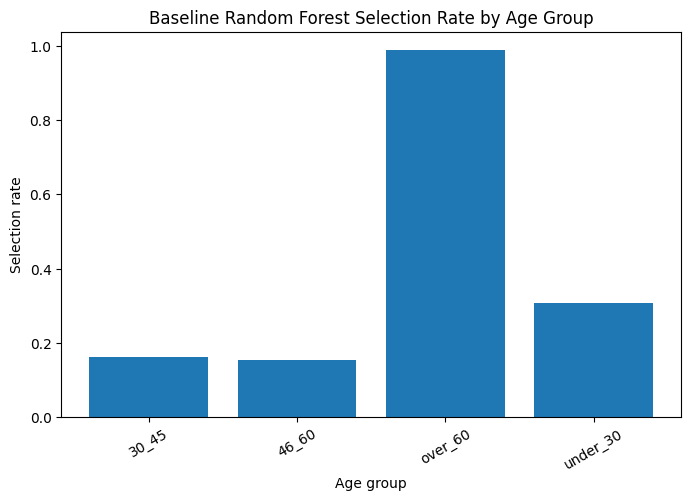

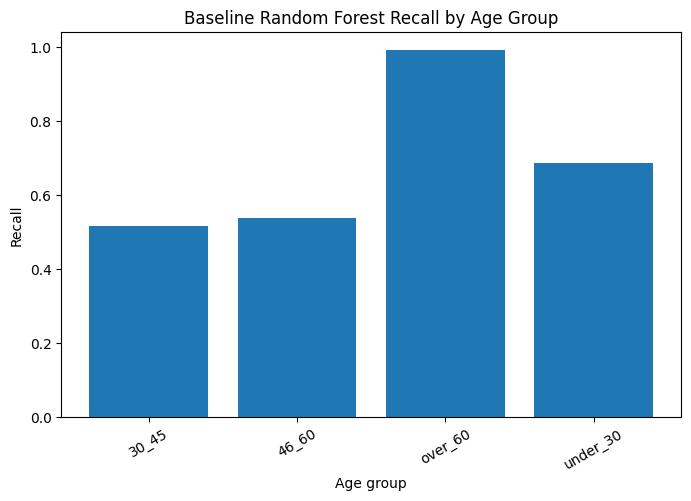

In [42]:
# Visualize selection rate and recall by age group
plot_table = rf_fairness_age.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_table["age_group"].astype(str), plot_table["selection_rate"])
plt.xlabel("Age group")
plt.ylabel("Selection rate")
plt.title("Baseline Random Forest Selection Rate by Age Group")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(plot_table["age_group"].astype(str), plot_table["recall"])
plt.xlabel("Age group")
plt.ylabel("Recall")
plt.title("Baseline Random Forest Recall by Age Group")
plt.xticks(rotation=30)
plt.show()

The model showed substantial differences across age groups, with the most notable differences at the over 60 age group.

Only about 15–31% of clients under 60 were predicted as likely subscribers, compared with 98% of clients over 60. This suggests that the model heavily prioritizes the over-60 group for marketing outreach. This is also the group for which random forest has the lowest accuracy, meaning that it's predictions for this group are not reliable. Looking at precision, it is the highest for this group, but even still is only at 42.6% meaning many predicted as subscribed didn't actually subscribe. The high recall of 99.1% is coming from the model predicting almost every client in this group as a subscriber. In practical terms, this means overtargeting the older customers basing off historical data patterns.

The  30–45 and 46–60 groups had much lower selection rates and higher false negative rates.This means the model is more likely to miss actual subscribers in middle-age groups, while almost never missing actual subscribers over 60. This creates unequal opportunity for outreach across age groups.

These results do not prove discrimination, but they do show group-level disparities that would require further auditing before deployment. A responsible bank marketing system should monitor selection rates, false positive rates, and false negative rates across customer groups, not just overall accuracy.

## Bias Mitigation / Imbalance Mitigation with SMOTE

The target variable is imbalanced because most customers do not subscribe to the term deposit.

SMOTE creates synthetic examples of the minority class in the training data. This may help the model identify actual subscribers, but it can also create tradeoffs such as lower precision or more false positives.


Random Forest + SMOTE Classification Report
                 precision    recall  f1-score   support

No Subscription       0.94      0.87      0.90      9981
   Subscription       0.35      0.55      0.43      1322

       accuracy                           0.83     11303
      macro avg       0.64      0.71      0.66     11303
   weighted avg       0.87      0.83      0.84     11303



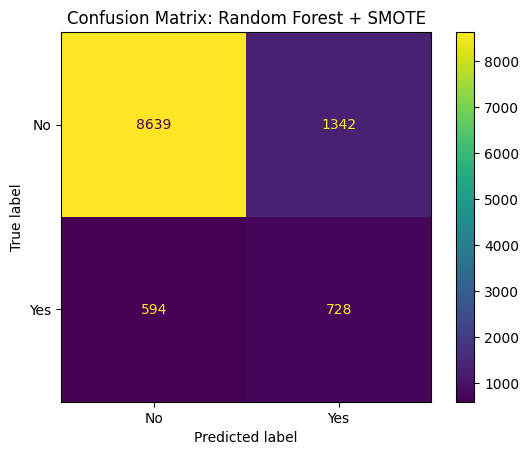

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.8222,0.3486,0.5991,0.4407,0.7939
1,Random Forest + SMOTE,0.8287,0.3517,0.5507,0.4292,0.7822


In [43]:
smote_rf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

smote_rf.fit(X_train, y_train)

smote_metrics, smote_pred, smote_proba = evaluate_model(smote_rf, X_test, y_test, "Random Forest + SMOTE")

comparison_results = pd.DataFrame([rf_metrics, smote_metrics])
display(comparison_results.round(4))

SMOTE didn't improve the model in a meaningful way. There was a slight increase in accuracy and precision but this came at the tradeoff of a slightly lowered recall and ROC - AUC

## 13. Compare Fairness Before and After SMOTE

Although SMOTE did not improve overall model performance, I also evaluated whether it changed fairness-related outcomes across age groups.

In [44]:
smote_fairness_age = group_fairness_table(y_test, smote_pred, age_test, "Random Forest + SMOTE")

fairness_comparison = pd.concat([rf_fairness_age, smote_fairness_age], axis=0)
display(fairness_comparison.round(4))

,age_group,selection_rate,accuracy,precision,recall,false_positive_rate,false_negative_rate,model
0,30_45,0.1612,0.8418,0.3072,0.5158,0.1236,0.4842,Random Forest Baseline
1,46_60,0.1543,0.8536,0.3683,0.5376,0.1090,0.4624,Random Forest Baseline
2,over_60,0.9890,0.4286,0.4259,0.9914,0.9873,0.0086,Random Forest Baseline
3,under_30,0.3067,0.7540,0.3647,0.6859,0.2328,0.3141,Random Forest Baseline
0,30_45,0.1498,0.8472,0.3105,0.4842,0.1142,0.5158,Random Forest + SMOTE
1,46_60,0.1449,0.8495,0.3455,0.4735,0.1061,0.5265,Random Forest + SMOTE
2,over_60,0.8498,0.5018,0.4569,0.9138,0.8025,0.0862,Random Forest + SMOTE
3,under_30,0.2690,0.7752,0.3851,0.6354,0.1976,0.3646,Random Forest + SMOTE


model,Random Forest + SMOTE,Random Forest Baseline
age_group,,
30_45,0.1498,0.1612
46_60,0.1449,0.1543
over_60,0.8498,0.9890
under_30,0.2690,0.3067


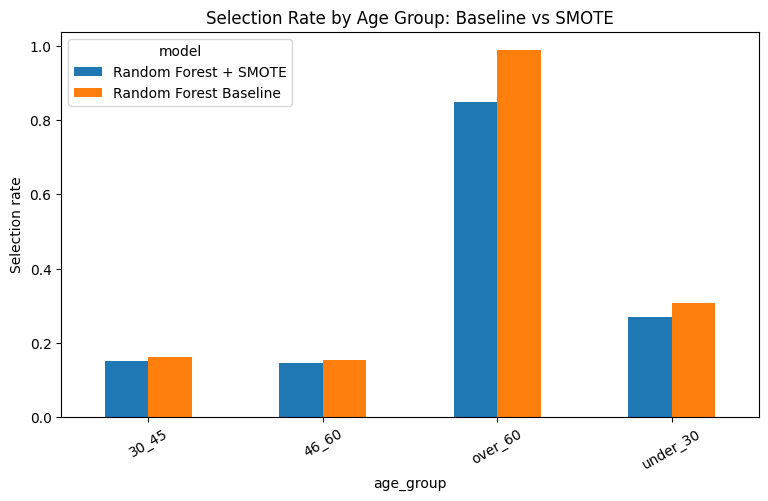

model,Random Forest + SMOTE,Random Forest Baseline
age_group,,
30_45,0.4842,0.5158
46_60,0.4735,0.5376
over_60,0.9138,0.9914
under_30,0.6354,0.6859


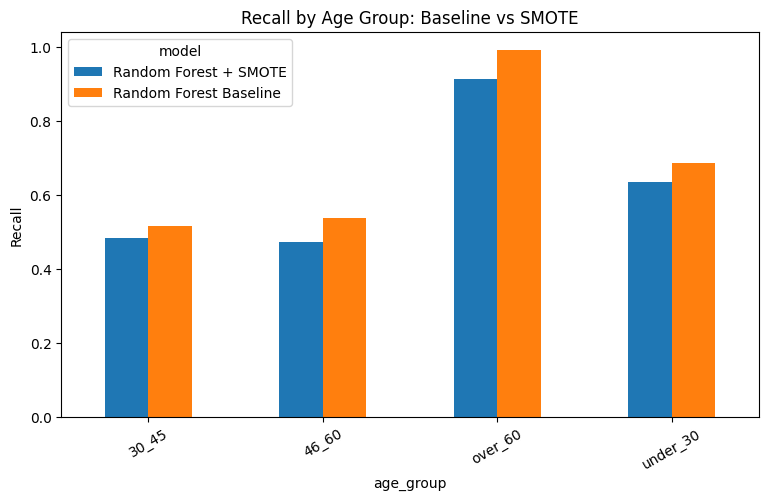

In [45]:
# Compare selection rate before and after SMOTE
pivot_selection = fairness_comparison.pivot(index="age_group", columns="model", values="selection_rate")
display(pivot_selection.round(4))

pivot_selection.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Selection rate")
plt.title("Selection Rate by Age Group: Baseline vs SMOTE")
plt.xticks(rotation=30)
plt.show()

# Compare recall before and after SMOTE
pivot_recall = fairness_comparison.pivot(index="age_group", columns="model", values="recall")
display(pivot_recall.round(4))

pivot_recall.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Recall")
plt.title("Recall by Age Group: Baseline vs SMOTE")
plt.xticks(rotation=30)
plt.show()

After SMOTE, the model is still highly prioritizing the "over 60" age group, meaning SMOTE didn't fix the age-group fairness disparities.However, SMOTE made the model more conservative, predicting subscription = yes less often across all groups, which can be evidence most significantly at the "selection rate" for over 60 which dropped to 85%.

Recall was lower across all groups, which is consistent with the overall model results (seen above)

## SHAP Explainability

This section explains the Random Forest model using SHAP.

Because the model uses one-hot encoding, SHAP is applied to the transformed feature matrix. The feature names are extracted from the preprocessing pipeline.


In [47]:
# Fit preprocessing and transform the data for SHAP
# We use the baseline Random Forest model.
fitted_preprocessor = rf.named_steps["preprocessor"]
fitted_rf_classifier = rf.named_steps["classifier"]

X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

# Convert sparse matrix to dense for SHA
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

feature_names = fitted_preprocessor.get_feature_names_out()

# Sample to run SHAP faster in Colab
sample_size = min(500, X_test_transformed.shape[0])
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_test_transformed.shape[0], sample_size, replace=False)

X_shap = X_test_transformed[sample_idx]
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

explainer = shap.TreeExplainer(fitted_rf_classifier)
shap_values = explainer.shap_values(X_shap)

print("SHAP values type:", type(shap_values))

SHAP values type: <class 'numpy.ndarray'>


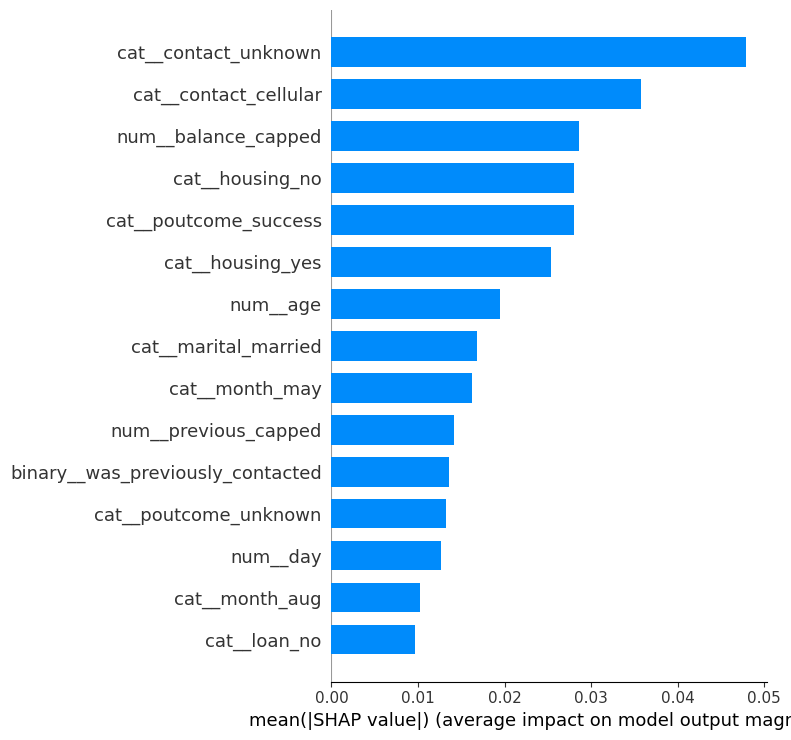

In [48]:
# For binary classification, shap_values may be a list with one array per class.
# We explain class 1: subscription = yes.
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    # Newer SHAP versions
    if len(np.array(shap_values).shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values

# SHAP global bar plot
shap.summary_plot(
    shap_values_class1,
    X_shap_df,
    plot_type="bar",
    max_display=15
)

This plot shows the features that have the largest overall impact on the model's predictions.

The SHAP bar plot shows that the most influential features for the baseline Random Forest were contact method, account balance, housing loan status, previous campaign outcome, and age.

The strongest feature was "contact_unknown", followed by "contact_cellular". This suggests that the model relies heavily on campaign process and contact-history variables. This is important because these features represent historical data trends, which we saw earlier had disparities and clear data quality issues.

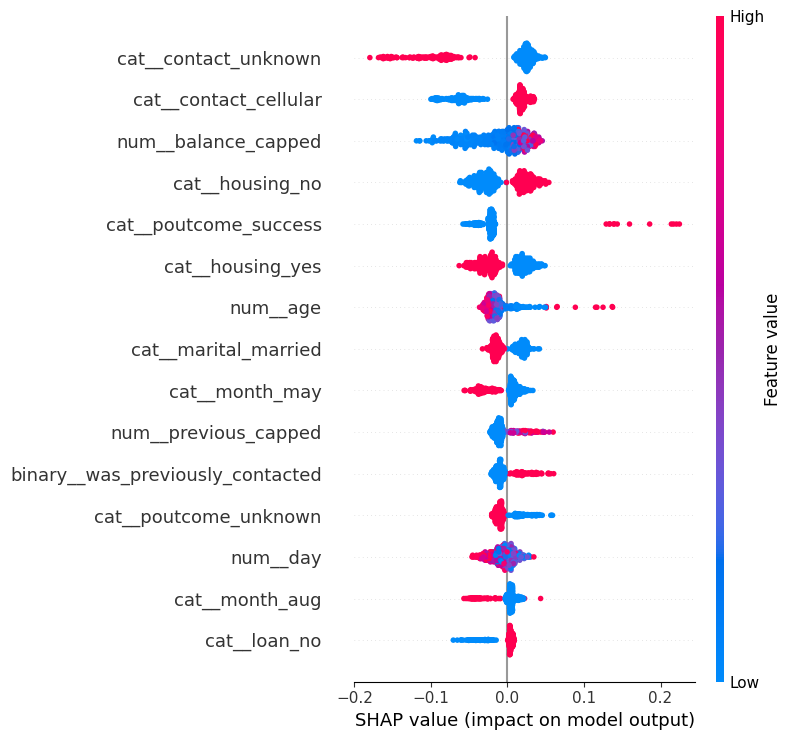

In [49]:
# SHAP beeswarm plot
shap.summary_plot(
    shap_values_class1,
    X_shap_df,
    max_display=15
)

"contact_unknown" generally pushed predictions away from subscription, while "contact_cellular" tended to push predictions toward subscription, which on marketing campaigns makes practical sense. Higher balances and prior campaign success also tended to increase the predicted likelihood of subscription. Housing loan status mattered as well: clients without a housing loan were generally pushed toward subscription, while clients with a housing loan were pushed away.

Age also influenced the model's predictions. This is important because the fairness analysis showed large differences in selection rates across age groups, especially for clients over 60.

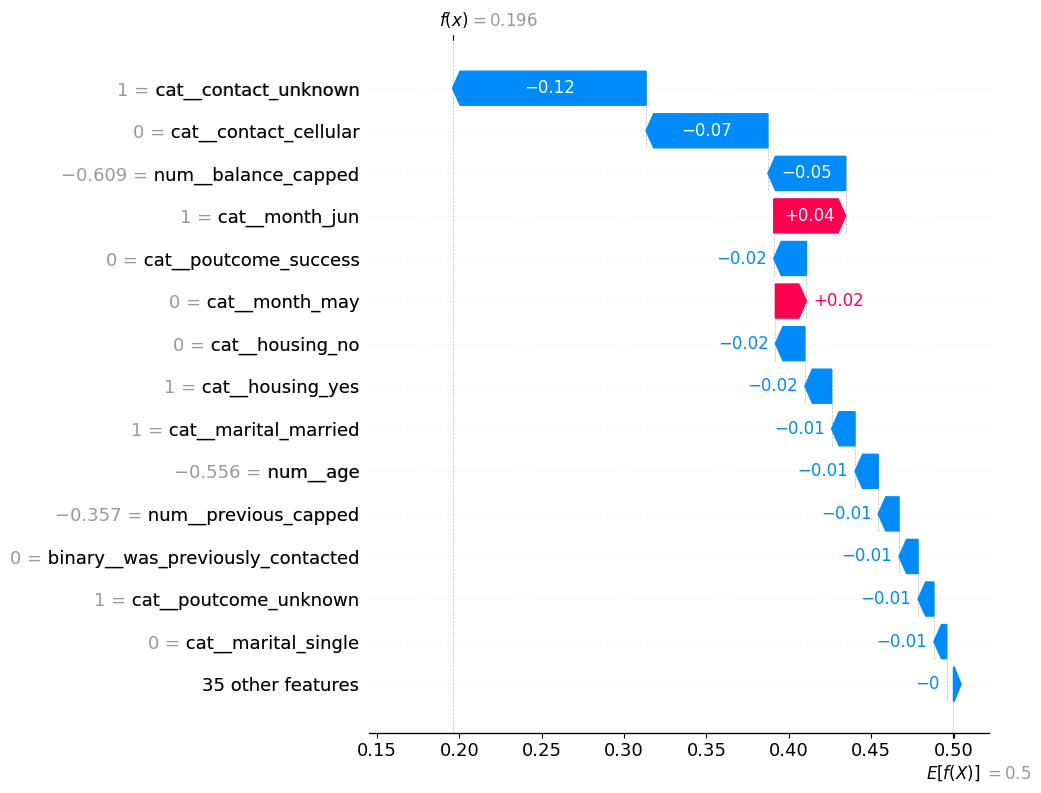

In [50]:
# SHAP waterfall plot for one customer
# This may require the expected value for class 1.
customer_index = 0

if isinstance(explainer.expected_value, list) or isinstance(explainer.expected_value, np.ndarray):
    expected_value_class1 = explainer.expected_value[1]
else:
    expected_value_class1 = explainer.expected_value

explanation = shap.Explanation(
    values=shap_values_class1[customer_index],
    base_values=expected_value_class1,
    data=X_shap_df.iloc[customer_index],
    feature_names=feature_names
)

shap.plots.waterfall(explanation, max_display=15)

For this specific customer, the prediction was mainly lowered because the contact method was unknown as well as cellular contact. The lower account balance also lowered the prediction as well as having housing loan. These last two features are important becuase they could be proxy for socioeconomic status.

##**Governance Recommendations**

Based on the model results, this bank marketing model should not be deployed as a fully automated targeting system without additional safeguards. Although the baseline Random Forest had the strongest overall performance, the Responsible AI evaluation showed important risks, especially large differences in model behavior across age groups and heavy reliance on campaign-history features.

### 1. Monitor fairness metrics across age groups

The model should be monitored using group-level metrics, not only overall accuracy. In this project, the model selected clients over 60 at a much higher rate than other age groups, while middle-age groups had higher false negative rates. Before deployment, the bank should regularly monitor selection rate, recall, false positive rate, and false negative rate across age groups.

This is important because a model can appear accurate overall while still over-targeting one group or overlooking another.

### 2. Review features tied to historical campaign practices

SHAP showed that features such as "contact_unknown", "contact_cellular", "poutcome_success", and "poutcome_unknown" influenced predictions. These features may reflect previous marketing practices, data availability, or campaign process decisions rather than stable customer interest.

The bank should review whether these features are appropriate for future targeting.

### 3. Avoid fully automated outreach decisions

The model should support human decision-making rather than automatically deciding who receives marketing outreach. Bank staff should use the model as one input among others, especially because the model showed age-group disparities and imperfect precision for predicting subscribers.

A human review process can help prevent over-reliance on model outputs and allow staff to consider business rules, customer preferences, and ethical concerns.

### 4. Re-evaluate the model over time

Customer behavior and marketing strategies can change. The model should be re-evaluated periodically using updated data. The bank should check whether model performance or fairness metrics drift over time, especially if campaign strategies, customer demographics, or contact methods change.

### 5. Provide an opt-out and customer impact review

Because this model could influence who receives marketing outreach, the bank should ensure customers have clear opt-out options and should monitor whether any group is being contacted excessively. This is especially important because the model strongly prioritized the over-60 group.

### 6. Do not assume mitigation automatically improves fairness

SMOTE did not clearly improve the model. It reduced some over-selection of older clients but also lowered recall across all age groups. This shows that mitigation techniques should be tested and evaluated directly rather than assumed to improve responsible AI outcomes.

## Limitations

This project has several limitations:

- The dataset does not include race or gender, so this is not a complete protected-class fairness audit.
- Age, and education are used for group analysis, but these are imperfect proxies for broader fairness concerns.
- The dataset reflects historical marketing outcomes, which may already include bias from previous campaign strategies.
- SMOTE didn't fully address class imbalance.
- SHAP explains model behavior, not real-world causality.